<a href="https://colab.research.google.com/github/AbdiR0099/pytorch_workflow_fundamentals/blob/main/PyTorch_Workflow_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.5.1+cu121'

In [ ]:
# Create Known Parameters
weight = 0.7
bias = 0.3
# Create Data
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
X.shape

torch.Size([50, 1])

In [ ]:
# Creating Training & Testing data split
split = int(0.8 * len(X)) # 80% data for training, 20% data for testing
X_train, Y_train = X[:split],Y[:split] # All data until split (80%)
X_test, Y_test = X[split:],Y[split:] # All data from split to end (Remaining 20%)
print(f"Total data Length: {len(X)}")
len(X_train),len(Y_train),len(X_test),len(Y_test)

Total data Length: 50


(40, 40, 10, 10)

In [ ]:
def plot(train_data = X_train,
         train_label = Y_train,
         test_data = X_test,
         test_label = Y_test,
         predictions = None):
  plt.figure(figsize=(10,5))

  # Plot Training Data
  plt.scatter(train_data, train_label, c="b", s = 30, label = "Training Data")
  # Plot Testing Data
  plt.scatter(test_data, test_label, c="m", s = 30, label = "Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions, c="r", s = 30, label="Predictions")

  plt.legend()

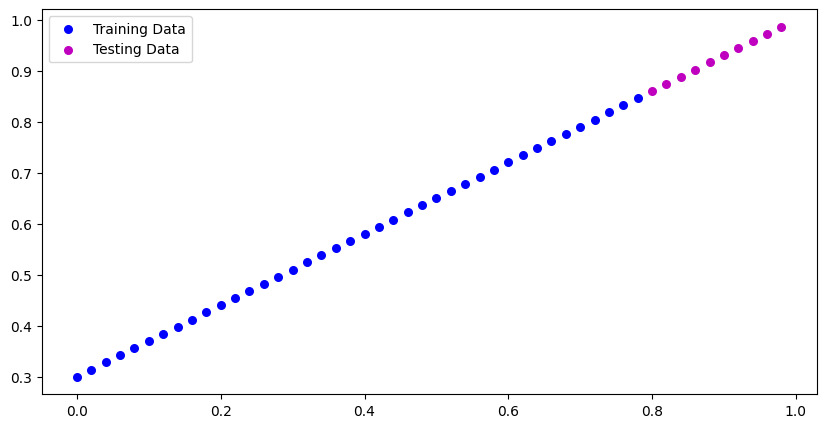

In [ ]:
plot()

*   **X (Features) & Y (Labels)**




In [ ]:
# Creating a Linear Regression Model
class LRM(nn.Module):
  def __init__(self):
    super().__init__()
    # Initialize Model Parameters
    self.weight = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
  # forward() must be defined in any subclass that inherits from nn.Module
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias # The linear Regression formula for y = w*X+b


#### **Creating An Instance of the Model**

In [ ]:
# As parameters are initlized randomly, manual_seed has to be set
torch.manual_seed(42)

# Create an instance of the model
model_0 = LRM()

# List Parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List Model Parameter
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

### **Make Predictions**

In [ ]:
with torch.inference_mode():
  y_preds = model_0(X_test)

In [ ]:
print(f"Length of Testing Data: {len(X_test)}\n")
print(f"Length of Prediction Data: {len(y_preds)}\n")
print(f"Prediction Data: \n{y_preds}")
# Data mapping 1-1, 1 prediction for 1 data point, however ML is flexible and can have multiple predictions for a single value or multiple values

Length of Testing Data: 10

Length of Prediction Data: 10

Prediction Data: 
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


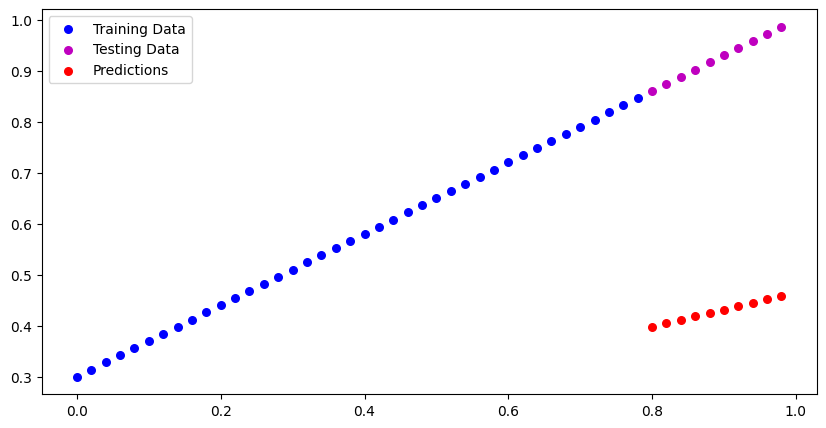

In [ ]:
plot(predictions=y_preds)

In [ ]:
Y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

### **Loss Function:**

Calculates how much difference, incorrect are the predictions (y_preds) from actual labels (Y_test). MAE, Mean Absolute Error is used for Linear Regression Tasks.

In [ ]:
loss_fn = nn.L1Loss()

### **Optimizer:**
Tells the model on how to finetune the parameters of the model to lower loss function. SGD (Stocastic Gradient Descent) will be used as an optimizer here.

*   Params are parameters of the model
*   Lr is the learning rate (how much the optimizer should change the parameters at each step, higher = more (less stable), lower = less (might take a long time)



In [ ]:
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01)

### **Training Function**

In [ ]:
def Training_Loop(X_train,Y_train):
  model_0.train() # Model in training Mode
  y_preds = model_0(X_train) # Make Predictions
  loss = loss_fn(y_preds,Y_train) # Calculate Loss
  optimizer.zero_grad() # Optimizer results accumulate so it is reset
  loss.backward() # Back propagate loss through the model
  optimizer.step()
  return loss


### **Testing function**

In [ ]:
def Testing_Loop(X_test,Y_test):
  model_0.eval()

  with torch.inference_mode():
    test_preds = model_0(X_test)
    test_loss = loss_fn(test_preds,Y_test.type(torch.float))
  # predictions come in torch.float datatype, hence for comparison, both tensors have to be same datatype
  return test_loss


### **Combining Loops:**
Now that the functions for training and testing are creating, we are going to create a loop and train and test the model.

In [ ]:
# Number of epochs (How many times the loops should run)
epochs = 100

epochs_count = []
training_loss = []
testing_loss = []
""" The empty lists are created to keep count of epochs and the loss during
regular intervals of the loops """

for epoch in range(epochs):
  fn_loss = Training_Loop(X_train=X_train,Y_train=Y_train)
  fn_testing_loss = Testing_Loop(X_test,Y_test)

  if epoch % 10 == 0:
    epochs_count.append(epoch)
    training_loss.append(fn_loss.detach().numpy())
    testing_loss.append(fn_testing_loss.detach().numpy())
    print(f"Epoch: {epoch} | MAE Train Loss: {fn_loss} | MAE Test Loss: {fn_testing_loss}\n")



Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495

Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428

Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688

Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703

Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106

Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024

Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135

Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519

Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484

Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819



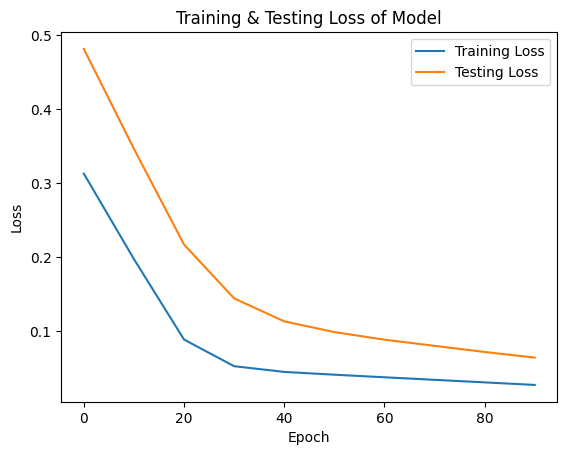

In [ ]:
plt.plot(epochs_count,training_loss,label= "Training Loss")
plt.plot(epochs_count,testing_loss,label= "Testing Loss")
plt.title("Training & Testing Loss of Model")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend();

In [ ]:
print(f"Parameter Values:\n{model_0.state_dict()}")
print(f"\nOriginal Values: Weight = {weight}, Bias = {bias}")

Parameter Values:
OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

Original Values: Weight = 0.7, Bias = 0.3


### **Making Predictions:**

Now that our model is trained, Lets see how it can prediction values that are similar to original values.

In [ ]:
# Put model in eval mode
model_0.eval()
# Use inference mode
with torch.inference_mode():
  make_predictions = model_0(X_test)

print(f"Predictions made by Model: \n{make_predictions}\n")
print(f"Original values of Y: \n{Y_test}")

Predictions made by Model: 
tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

Original values of Y: 
tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


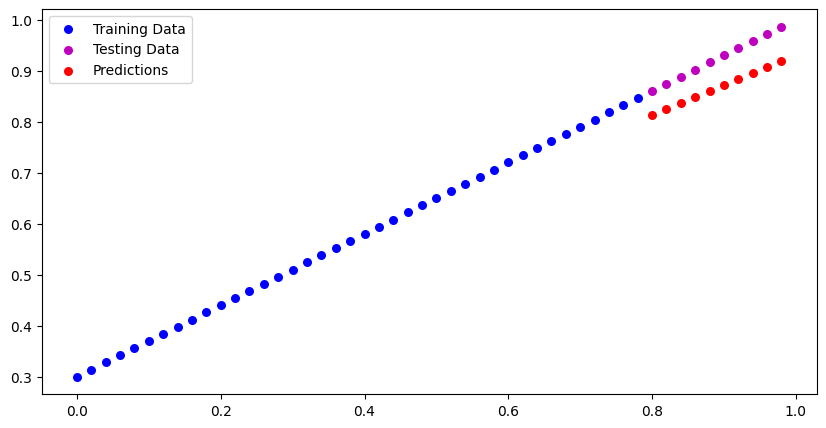

In [ ]:
plot(predictions = make_predictions)

### **Saving Model**


*   ***torch.save:*** Saves a serialized object to disk using Python's pickle utility. Models, Tensors and various other python objects like dictionaries can be saved using `torch.save`.

*   ***torch.load:*** Uses pickle's unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc).

* ***torch.nn.Module.load_state_dict:*** Loads a model's parameter dictionary `(model.state_dict())` using a saved `state_dict()` object.



### **Saving a PyTorch Model's `state_dict()`**

In [ ]:
from pathlib import Path

# 1. Create a directory to save model (folder Name)
Model_Path = Path("models")
Model_Path.mkdir(parents=True,exist_ok=True)

# 2. Create Saving Path for Model (File Name)
Model_Name = "01_First_Model.pth"
Model_Save_Path = Model_Path / Model_Name # Folder + File

# 3. Save the model state_dict
print(f"Model Saving to: {Model_Save_Path}")
torch.save(obj = model_0.state_dict(), f = Model_Save_Path) # Save
# Saving the state_dict() means saving the models learned parameters only


Model Saving to: models/01_First_Model.pth


In [ ]:
# Check saved model file path
!ls -l models/01_First_Model.pth

-rw-r--r-- 1 root root 1538 Jan 11 18:35 models/01_First_Model.pth


### **Loading a saved PyTorch Model's `state_dict()`**

In [ ]:
loaded_model = LRM()

In [ ]:
loaded_model.load_state_dict(torch.load(f=Model_Save_Path))
loaded_model.state_dict()

<ipython-input-26-d81796ff0226>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(f=Model_Save_Path))


OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [ ]:
loaded_model.eval()
with torch.inference_mode():
  loaded_preds = loaded_model(X_test)

In [ ]:
loaded_preds == y_preds
## False because function is being made for training and not directly a loop above

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

## **The Full Code on GPU**

In [ ]:
# Libraries
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.5.1+cu121'

In [ ]:
# Make Device agnostic (Use GPU if available)
device = "cuda" if torch.cuda.is_available() else "CPU"
device

'cuda'

In [ ]:
# Hard-Coded Parameters
weight = 0.3
bias = 0.9
# Data
start = 0
end = 50
step = 0.5
X = torch.arange(start,end,step).reshape(100,1)
Y = weight * X + bias
X[:5],Y[:5]

(tensor([[0.0000],
         [0.5000],
         [1.0000],
         [1.5000],
         [2.0000]]),
 tensor([[0.9000],
         [1.0500],
         [1.2000],
         [1.3500],
         [1.5000]]))

In [ ]:
# Split Data 80/20
split = int(len(X)*0.8)
X_train,X_test = X[:split],X[split:]
Y_train,Y_test = Y[:split],Y[split:]
print(f"X_train:{len(X_train)}\nX_test:{len(X_test)}\nY_train:{len(Y_train)}\nY_test:{len(Y_test)}")

X_train:80
X_test:20
Y_train:80
Y_test:20


In [ ]:
# Plot data
def Plot(Training_data=X_train,Training_labels=Y_train,
         Testing_data=X_test,Testing_labels=Y_test,predictions = None):
  plt.figure(figsize=(10,7))
  # plot training data
  plt.scatter(Training_data,Training_labels,s=4,c="b",label = "Training DATA")
  # plot testing data
  plt.scatter(Testing_data,Testing_labels,s=4,c="g",label = "Testing DATA")

  # predictions
  if predictions is not None:
    plt.scatter(Testing_data,predictions,s=4,c= "m", label = "Predictions")

  plt.legend()

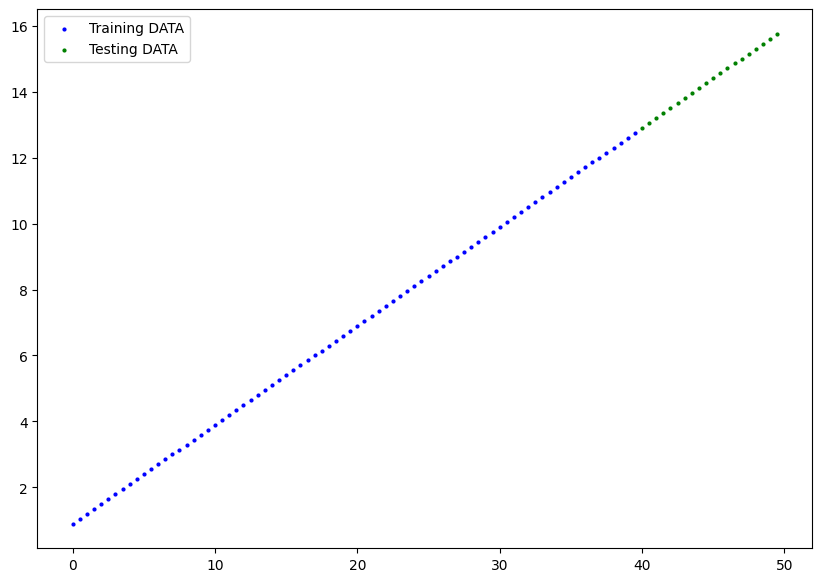

In [ ]:
Plot()

In [ ]:
# Create Model Object
class LRM(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,out_features=1)
    # in_features = 1 because 1 Value of X Maps to 1 value of Y out_features = 1

  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Create Instance
torch.manual_seed(42)
model = LRM()
model,model.state_dict()


(LRM(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check Model Device
next(model.parameters()).device

device(type='cpu')

In [ ]:
# Put the model on GPU
model.to(device)
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(lr = 0.001, params = model.parameters())
# lr is set low as the results with 0.01 were not accurate

In [ ]:
# Flavour the randomness
torch.manual_seed(42)
# Put the data on GPU as well
X_train = X_train.to(device)
X_test = X_test.to(device)
Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

epochs = 300

for epoch in range(epochs):
  # Training Loop
  # 1. Put model in train mode
  model.train()
  # 2. Make Predictions
  y_preds = model(X_train)
  # 3. Loss
  loss = loss_fn(y_preds,Y_train)
  # 4. Optimizer Zero Grad
  optimizer.zero_grad()
  # 5. Loss Backpropagate
  loss.backward()
  # 6. Optimizer Step
  optimizer.step()

  # Testing Loop
  # 1. Put model in eval mode
  model.eval()
  # 2. Make predictions
  with torch.inference_mode():
    testing_preds = model(X_test)
    testing_loss = loss_fn(testing_preds,Y_test)

  if epoch % 20 == 0:
    print(f"\nEpoch: {epoch}\nMAE Training Loss: {loss}\nMAE Testing Loss: {testing_loss}")





Epoch: 0
MAE Training Loss: 9.106393814086914
MAE Testing Loss: 19.83331871032715

Epoch: 20
MAE Training Loss: 1.2893446683883667
MAE Testing Loss: 2.142216920852661

Epoch: 40
MAE Training Loss: 0.09730792790651321
MAE Testing Loss: 0.778465747833252

Epoch: 60
MAE Training Loss: 0.11624089628458023
MAE Testing Loss: 0.7326557040214539

Epoch: 80
MAE Training Loss: 0.09476182609796524
MAE Testing Loss: 0.7785072922706604

Epoch: 100
MAE Training Loss: 0.1538132280111313
MAE Testing Loss: 0.6419538855552673

Epoch: 120
MAE Training Loss: 0.055208731442689896
MAE Testing Loss: 0.8624313473701477

Epoch: 140
MAE Training Loss: 0.1256875991821289
MAE Testing Loss: 0.6997639536857605

Epoch: 160
MAE Training Loss: 0.04456431046128273
MAE Testing Loss: 0.8808854222297668

Epoch: 180
MAE Training Loss: 0.10317474603652954
MAE Testing Loss: 0.7457113862037659

Epoch: 200
MAE Training Loss: 0.03540531545877457
MAE Testing Loss: 0.7660439014434814

Epoch: 220
MAE Training Loss: 0.032011836767

In [ ]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.3007]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.8366], device='cuda:0'))])

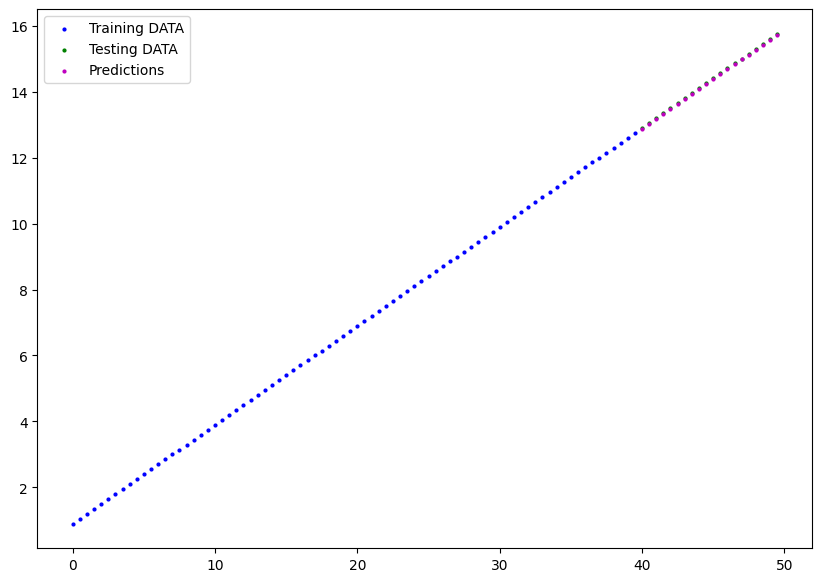

In [ ]:
# Making Predictions
model.eval()
with torch.inference_mode():
  now_preds = model(X_test)

Plot(predictions = now_preds.cpu()) # Has to be on CPU

In [ ]:
# Saving the Model
from pathlib import Path
Model_Path = Path("model_CUDA")
Model_Path.mkdir(parents=True,exist_ok = True)

Model_Name = "01_models_CUDA.pth"
Model_Save_PATH = Model_Path / Model_Name

torch.save(obj = model.state_dict(), f = Model_Save_PATH)


In [ ]:
# Loading Model

New_Loaded = LRM()
New_Loaded.load_state_dict(torch.load(Model_Save_PATH))
New_Loaded.to(device)
print(f"Loaded Model{New_Loaded}")
next(New_Loaded.parameters()).device

Loaded ModelLRM(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


<ipython-input-43-4e3578d0e801>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  New_Loaded.load_state_dict(torch.load(Model_Save_PATH))


device(type='cuda', index=0)

In [ ]:
print(f"New Model Parameters:\n{New_Loaded.state_dict()}")

New Model Parameters:
OrderedDict([('linear_layer.weight', tensor([[0.3007]], device='cuda:0')), ('linear_layer.bias', tensor([0.8366], device='cuda:0'))])


In [ ]:
# Make Predictions with new model

New_Loaded.eval()
with torch.inference_mode():
  y_preds = New_Loaded(X_test)

y_preds == now_preds



tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

In [ ]:
y_preds.ndim,y_preds.shape

(2, torch.Size([20, 1]))